# Behavioural sequence analysis
This script is used to check the behavioural sequences and quickly see what they look like
The existing code can easily duplicated in additional cells to check other aspects of the 'parameters_per_stimuli' file

In [41]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import utils
import re

#pd.set_option('display.max_rows', None)

In [42]:
# Make output folder if non-existent
output_dir = os.path.join('..','plots','sequences')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [43]:
# Load the path and read the CSV
subject_id = [920]
session_number = [1]
experiment_output_path = os.path.join('..', '..', 'phd_1_task', 'experiment_output')

sequence_path = [os.path.join('..', '..', 'phd_1_task', 'sequences', f'parameters_per_stimuli_sub-{subject_id[0]:003}_session-{session_number[0]:02}.csv')]
sequence_dataframe = pd.read_csv(sequence_path[0], sep=';')

#filename = os.path.join('..', '..', 'phd_1_task', 'experiment_output', 'behavioural_files',  f'experiment_output_sub-{subject_id[0]:003}_session-{session_number[0]:02}_computer_and_keyboard_2024-06-12_18-02-24.csv')
#pd.read_csv(filename, sep=';')

# Adding a helper column 'entry' to keep track of the count of each type
sequence_dataframe['trial'] = sequence_dataframe.groupby('stimuli_type').cumcount()
unique_stimuli_types = sorted(sequence_dataframe['stimuli_type'].unique())

# Pivot the DataFrame using the new 'entry' column as the index
probability_dataframe_pivoted = sequence_dataframe.pivot(index = 'trial', columns = 'stimuli_type', values = 'probability_condition')

In [44]:
# Determine if there's a change in any column from the previous row
probability_dataframe_pivoted['change'] = probability_dataframe_pivoted[unique_stimuli_types].ne(probability_dataframe_pivoted[unique_stimuli_types].shift()).any(axis=1)

# Assigning a block ID for each group of unchanged rows
probability_dataframe_pivoted['block_id'] = probability_dataframe_pivoted['change'].cumsum()

# Counting rows since the last change
probability_dataframe_pivoted['rows_since_change'] = probability_dataframe_pivoted.groupby('block_id').cumcount()

# Optionally, remove the helper columns
probability_dataframe_pivoted.drop(columns=['change', 'block_id'], inplace=True)

# Print to check
print(probability_dataframe_pivoted)

stimuli_type   1   3  rows_since_change
trial                                  
0             50  50                  0
1             50  50                  1
2             50  50                  2
3             50  50                  3
4             20  80                  0
...           ..  ..                ...
335           20  80                  7
336           20  80                  8
337           20  80                  9
338           20  80                 10
339           20  80                 11

[340 rows x 3 columns]


## Probability sequence
### Plot all probability sequences together
As seen in Ly's paper from 2014

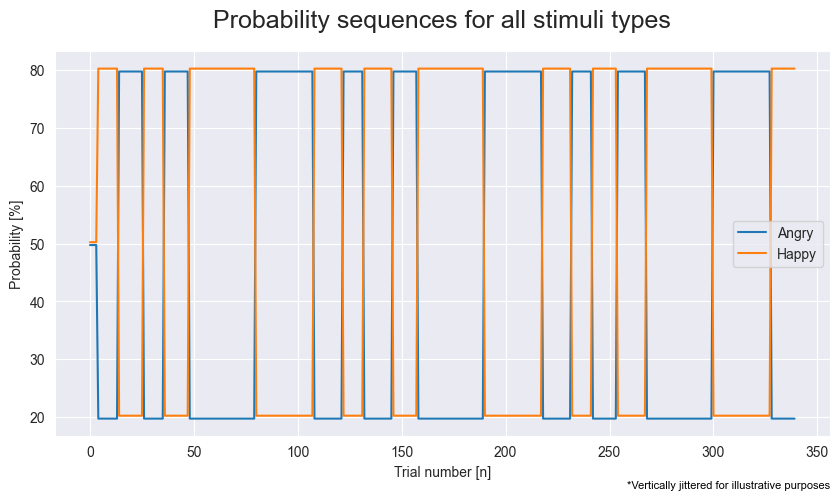

In [45]:
# Jitter vertically to make the lines easier to read when overlapping
jitter_strength = [0.25, -0.25]
stimuli_type_names = ['Angry','Angry reward','Happy','Happy reward']
note = '*Vertically jittered for illustrative purposes'
# Plot all stimuli types together
fig, ax = plt.subplots(figsize=(10, 5))
for index, value in enumerate(unique_stimuli_types):
    column_data = probability_dataframe_pivoted[value] + jitter_strength[index-1]
    plt.plot(column_data, label=stimuli_type_names[value-1])
plt.title('Probability sequences for all stimuli types', fontsize=18, y=1.04)
plt.xlabel('Trial number [n]')
plt.ylabel('Probability [%]')
plt.legend()
plt.text(1, -0.14, note, transform=ax.transAxes, horizontalalignment='right', verticalalignment='bottom',
         fontsize=8, color='black')
plt.savefig(os.path.join(output_dir, f'probability_sequence_all_stimuli_types_sub-{subject_id[0]:003}_session-{session_number[0]:02}.pdf'))
plt.show()

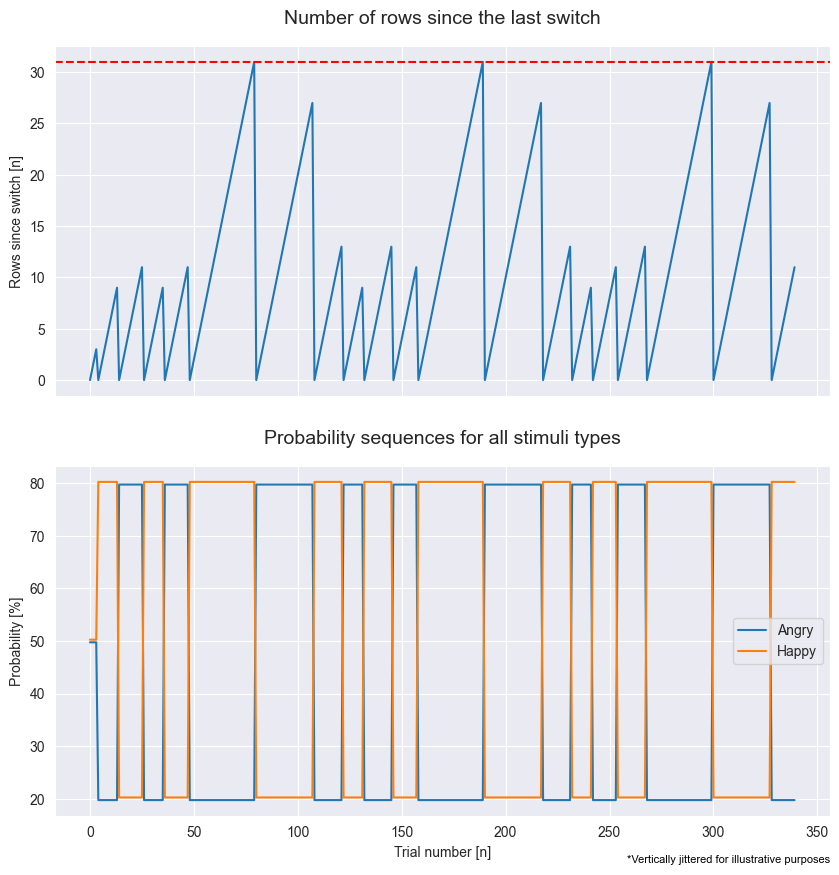

In [46]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True, sharey=False)

# Plot the time since the last switch
max_rows_since_change = probability_dataframe_pivoted['rows_since_change'].max()
ax1.plot(probability_dataframe_pivoted['rows_since_change'])
ax1.axhline(max_rows_since_change, color='r', linestyle='--', label='Max rows before switch')
ax1.set_title('Number of rows since the last switch', fontsize=14, y=1.04)
ax1.set_ylabel('Rows since switch [n]')

# Plot all stimuli types together
for index, value in enumerate(unique_stimuli_types):
    column_data = probability_dataframe_pivoted[value] + jitter_strength[index-1]
    ax2.plot(column_data, label=stimuli_type_names[value-1])
ax2.set_title('Probability sequences for all stimuli types', fontsize=14, y=1.04)
ax2.set_xlabel('Trial number [n]')
ax2.set_ylabel('Probability [%]')
ax2.legend()
ax2.text(1, -0.14, note, transform=ax2.transAxes, horizontalalignment='right', verticalalignment='bottom',
        fontsize=8, color='black')
plt.savefig(os.path.join(output_dir, f'probability_sequence_with_time_since_switch_all_stimuli_types_sub-{subject_id[0]:003}_session-{session_number[0]:02}.pdf'))
plt.show()

# Calculating the correlation
This should not be too high since we want people to track the stimuli independently

In [47]:
correlation_matrix = probability_dataframe_pivoted[unique_stimuli_types].corr()
print(correlation_matrix)

stimuli_type    1    3
stimuli_type          
1             1.0 -1.0
3            -1.0  1.0


### Now plot them separately
To take a proper look at each sequence separately

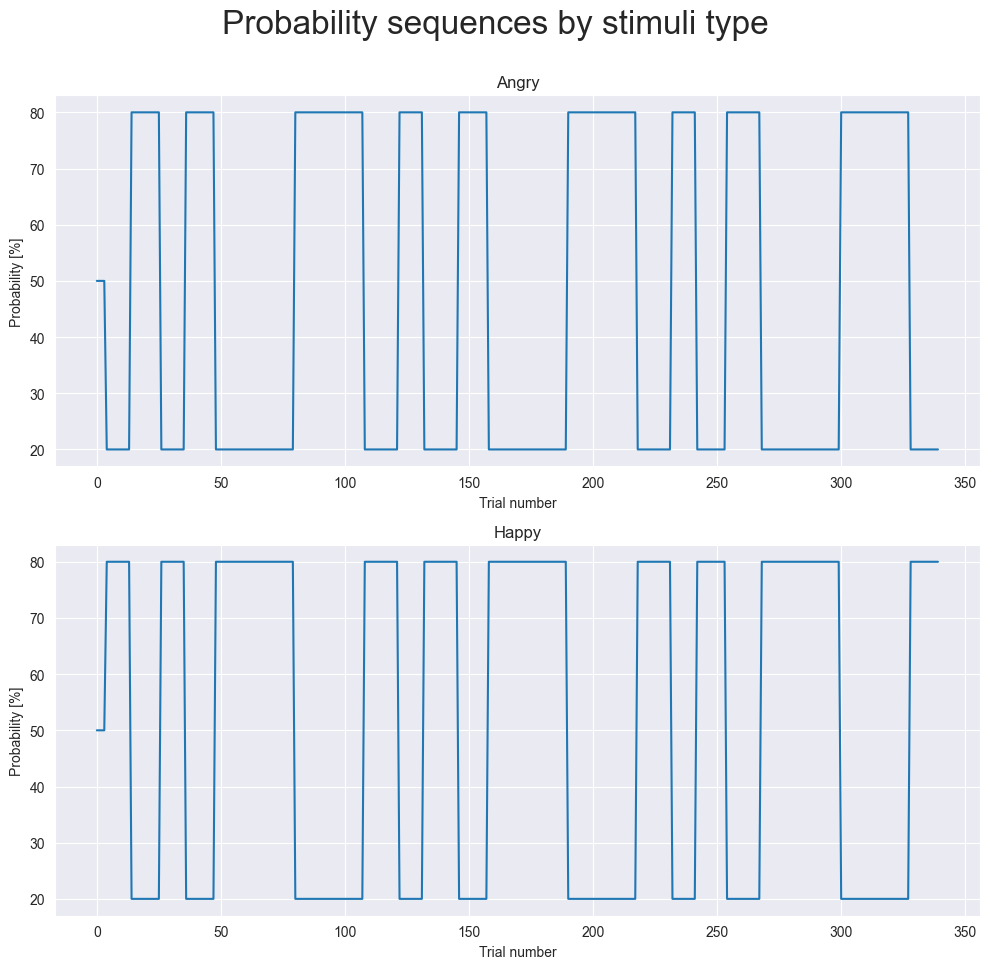

In [48]:
# Plot each stimuli type in a separate subplot
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))
fig.suptitle('Probability sequences by stimuli type', fontsize=24, y=0.965)

for i, ax in enumerate(axes.flatten()):
    ax.plot(probability_dataframe_pivoted[unique_stimuli_types[i]].dropna())  # dropna() is used because pivoting can introduce NaN values
    ax.set_title(stimuli_type_names[unique_stimuli_types[i]-1])
    ax.set_xlabel('Trial number')
    ax.set_ylabel('Probability [%]')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the layout to make room for the main title
plt.savefig(os.path.join(output_dir, f'probability_sequence_per_stimuli_type_sub-{subject_id[0]:003}_session-{session_number[0]:02}.pdf'))
plt.show()